### Analisis de procesamiento de señales - UNSAM <img src=./logo_UNSAM.jpg align=right width=150>
## TS3: Análisis de Fourier: Primeras nociones de estimación espectral
### Lanzavechia, Jerónimo

Aclaración: El formateo de los gráficos y las porciones del documento en Latex se hicieron con asistencia de Chat-GPT

## Introducción

## Desarrollo


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import mi_libreria as lib
import scipy.fft as scfft
import scipy.signal.windows as window

### Señal con SNR = 3DB

In [2]:
N = 1000
fs = 1000
A = np.sqrt(2)

#En la implementacion agregue para generar una uniforme, asi que la uso para eso
P = 2

SNR = 3 #el seno tiene potencia 1W
P_ruido = 1 * 10**(-SNR/10)

tt,na_3dB = lib.mi_ruido(P_ruido, "normal", 0, N, fs)

#En la implementacion agregue para generar una uniforme, asi que la uso para eso
R = 200

####################para la frecuencia################
tt,u = lib.mi_ruido(P, "uniform" , 0, R, fs) ##frecuencia

fr = np.pi/2 + np.array(u)*2*np.pi/N

nn = np.arange(start = 0, stop = N, step = 1)

fr_x_n = nn.reshape(1,N) * fr.reshape(R,1) #NxR
###################para la frecuencia#################

#los 200 ruidos
na_3dB_m = np.random.normal(0,np.sqrt(P_ruido),size=(R,N))

##los 200 senos
senos = A * np.sin(fr_x_n) + na_3dB_m

### analisis

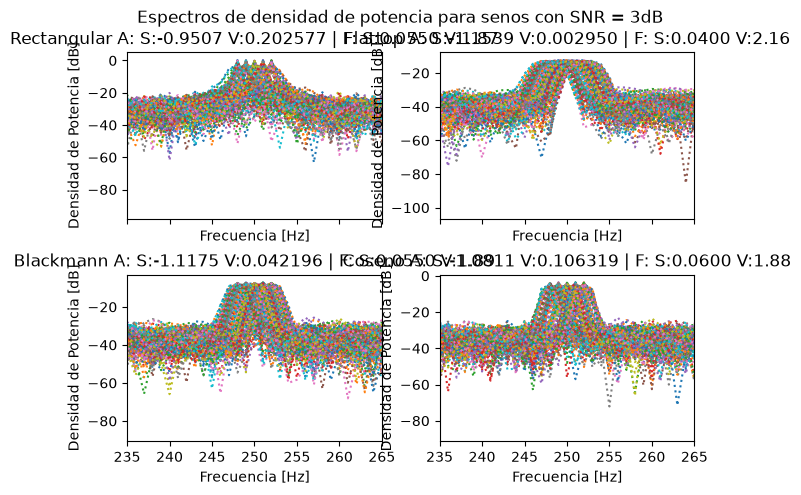

In [3]:
fig_3SNR, ((rectangular_3, flattop_3),( blackmann_3, coseno_3)) = plt.subplots(2,2, sharex=True)
fig_3SNR.suptitle("Espectros de densidad de potencia para senos con SNR = 3dB")
fig_3SNR.tight_layout(h_pad = 3)

#ventana rectangular
#al ventanear por una rectangular de N, es lo mismo que ver la funcion por la 
#ventana

seno_x_rectangular =  senos

ww = np.arange(start = 0, stop = fs/2, step = fs/N)
trafo_signal_N = 1/N * scfft.fft(seno_x_rectangular,N)[:,:N//2]
modulo_trafo_signal = np.abs(2*trafo_signal_N)
modulo_db = 20 * np.log10(modulo_trafo_signal/A)


##estimador de a 

a = (1 / R) *np.sum(modulo_trafo_signal[:,N//4])

#sesgo
S_a_rec = a - A

##varianza
V_a_rec = np.var(modulo_trafo_signal[:,N//4])

##estimador de frecuencia
f_max_rec = []
for i in range(200):
    f_max_rec.append(np.argmax(modulo_trafo_signal[i]))
    
f_max_rec = np.array(f_max_rec)

#sesgo

E_a = (1 / R) *np.sum(f_max_rec)
S_f_rec = E_a - N/4

#varianza

V_f_rec = np.var(f_max_rec)

########plot#############

rectangular_3.set_title(f"Rectangular A: S:{S_a_rec:.4f} V:{V_a_rec:.6f} | F: S:{S_f_rec:.4f} V:{V_f_rec:.2f}")
rectangular_3.set_xlabel("Frecuencia [Hz]")
rectangular_3.set_ylabel("Densidad de Potencia [dB]")
for i in range(R):
    rectangular_3.plot(ww,modulo_db[i],':')
rectangular_3.set_xlim(235*fs/N,265*fs/N) #comparten los ejes, los acerco en ese rango de x para ver la forma del espectro#
##############################################################################

#ventana flattop
flattop = window.flattop(N)

seno_x_flattop =  senos * flattop 

ww = np.arange(start = 0, stop = fs/2, step = fs/N)
trafo_signal_N = 1/N * scfft.fft(seno_x_flattop ,N)[:,:N//2]
modulo_trafo_signal = np.abs(2*trafo_signal_N)
modulo_db = 20 * np.log10(modulo_trafo_signal/A)

##estimador de a 

a = (1 / R) *np.sum(modulo_trafo_signal[:,N//4])

#sesgo
S_a_flat = a - A

##varianza
V_a_flat = np.var(modulo_trafo_signal[:,N//4])

##estimador de frecuencia
f_max_flat = []
for i in range(200):
    f_max_flat.append(np.argmax(modulo_trafo_signal[i]))
    
f_max_flat = np.array(f_max_flat)

#sesgo

E_a = (1 / R) *np.sum(f_max_flat)
S_f_flat = E_a - N/4

#varianza

V_f_flat = np.var(f_max_flat)

########plot#############

flattop_3.set_title(f"Flattop A: S:{S_a_flat:.4f} V:{V_a_flat:.6f} | F: S:{S_f_flat:.4f} V:{V_f_flat:.2f}")
flattop_3.set_xlabel("Frecuencia [Hz]")
flattop_3.set_ylabel("Densidad de Potencia [dB]")
for i in range(R):
    flattop_3.plot(ww,modulo_db[i],':')

##############################################################################


#ventana blackmanharris

blackmanharris = window.blackman(N)

seno_x_blackmanharris =  senos * blackmanharris 

ww = np.arange(start = 0, stop = fs/2, step = fs/N)
trafo_signal_N = 1/N * scfft.fft(seno_x_blackmanharris,N)[:,:N//2]
modulo_trafo_signal = np.abs(2*trafo_signal_N)
modulo_db = 20 * np.log10(modulo_trafo_signal/A)

##estimador de a 

a = (1 / R) *np.sum(modulo_trafo_signal[:,N//4])

#sesgo
S_a_black = a - A

##varianza
V_a_black = np.var(modulo_trafo_signal[:,N//4])

##estimador de frecuencia
f_max_black = []
for i in range(200):
    f_max_black.append(np.argmax(modulo_trafo_signal[i]))
    
f_max_black = np.array(f_max_black)

#sesgo

E_a = (1 / R) *np.sum(f_max_black)
S_f_black = E_a - N/4

#varianza

V_f_black = np.var(f_max_black)

########plot#############

blackmann_3.set_title(f"Blackmann A: S:{S_a_black:.4f} V:{V_a_black:.6f} | F: S:{S_f_black:.4f} V:{V_f_black:.2f}")
blackmann_3.set_xlabel("Frecuencia [Hz]")
blackmann_3.set_ylabel("Densidad de Potencia [dB]")
for i in range(R):
    blackmann_3.plot(ww,modulo_db[i],':')

#############################################################################

#Ventana a eleccion: 

cosine = window.cosine(N)

seno_x_cosine = senos * cosine

ww = np.arange(start = 0, stop = fs/2, step = fs/N)
trafo_signal_N = 1/N * scfft.fft(seno_x_cosine,N)[:,:N//2]
modulo_trafo_signal = np.abs(2*trafo_signal_N)
modulo_db = 20 * np.log10(modulo_trafo_signal/A)

##estimador de a 

a = (1 / R) *np.sum(modulo_trafo_signal[:,N//4])

#sesgo
S_a_cos = a - A

##varianza
V_a_cos = np.var(modulo_trafo_signal[:,N//4])

##estimador de frecuencia
f_max_cos = []
for i in range(200):
    f_max_cos.append(np.argmax(modulo_trafo_signal[i]))
    
f_max_cos = np.array(f_max_cos)

#sesgo

E_a = (1 / R) *np.sum(f_max_cos)
S_f_cos = E_a - N/4

#varianza

V_f_cos = np.var(f_max_cos)

########plot#############

coseno_3.set_title(f"Coseno A: S:{S_a_cos:.4f} V:{V_a_cos:.6f} | F: S:{S_f_cos:.4f} V:{V_f_cos:.2f}")
coseno_3.set_xlabel("Frecuencia [Hz]")
coseno_3.set_ylabel("Densidad de Potencia [dB]")
for i in range(R):
    coseno_3.plot(ww,modulo_db[i],':')
#############################################################################

### Histograma

(array([33.,  0., 42.,  0.,  0., 46.,  0., 38.,  0., 41.]),
 array([248. , 248.4, 248.8, 249.2, 249.6, 250. , 250.4, 250.8, 251.2,
        251.6, 252. ]),
 [<matplotlib.patches.Polygon at 0x721985717b90>])

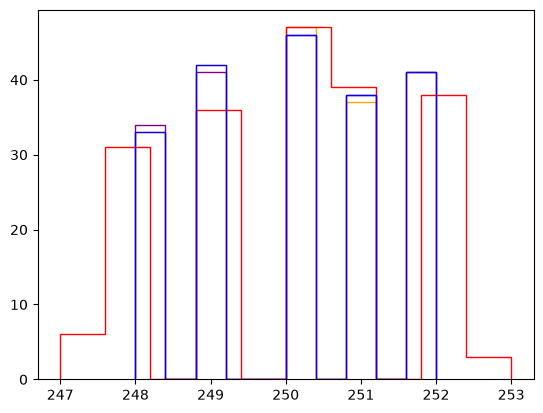

In [4]:
plt.figure(10)
plt.hist(f_max_rec, color = 'orange', histtype='step')
plt.hist(f_max_flat, color = 'red', histtype='step')
plt.hist(f_max_black, color = 'purple', histtype='step')
plt.hist(f_max_cos, color = 'blue', histtype='step')

### Señal con SNR = 10dB

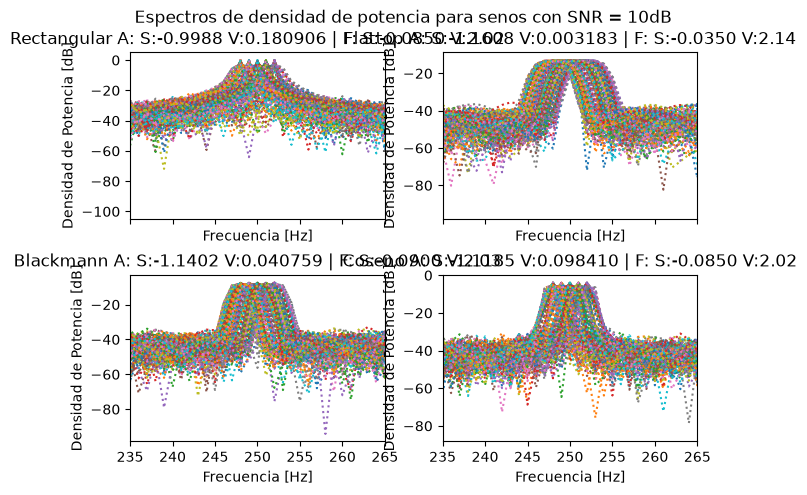

In [5]:
N = 1000
fs = 1000
A = np.sqrt(2)

#En la implementacion agregue para generar una uniforme, asi que la uso para eso
P = 2

SNR = 10 #el seno tiene potencia 1W
P_ruido = 1 * 10**(-SNR/10)

tt,na_3dB = lib.mi_ruido(P_ruido, "normal", 0, N, fs)

#En la implementacion agregue para generar una uniforme, asi que la uso para eso
R = 200

####################para la frecuencia################
tt,u = lib.mi_ruido(P, "uniform" , 0, R, fs) ##frecuencia

fr = np.pi/2 + np.array(u)*2*np.pi/N

nn = np.arange(start = 0, stop = N, step = 1)

fr_x_n = nn.reshape(1,N) * fr.reshape(R,1) #NxR
###################para la frecuencia#################

#los 200 ruidos
na_10dB_m = np.random.normal(0,np.sqrt(P_ruido),size=(R,N))

##los 200 senos
senos = A * np.sin(fr_x_n) + na_10dB_m

#Ventanas SNR = 10dB

fig_10SNR, ((rectangular_10, flattop_10),( blackmann_10, coseno_10)) = plt.subplots(2,2, sharex=True)
fig_10SNR.suptitle("Espectros de densidad de potencia para senos con SNR = 10dB")
fig_10SNR.tight_layout(h_pad = 3)





#ventana rectangular
#al ventanear por una rectangular de N, es lo mismo que ver la funcion por la 
#ventana

seno_x_rectangular =  senos

ww = np.arange(start = 0, stop = fs/2, step = fs/N)
trafo_signal_N = 1/N * scfft.fft(seno_x_rectangular,N)[:,:N//2]
modulo_trafo_signal = np.abs(2*trafo_signal_N)
modulo_db = 20 * np.log10(modulo_trafo_signal/A)


##estimador de a 

a = (1 / R) *np.sum(modulo_trafo_signal[:,N//4])

#sesgo
S_a_rec = a - A

##varianza
V_a_rec = np.var(modulo_trafo_signal[:,N//4])

##estimador de frecuencia
f_max_rec = []
for i in range(200):
    f_max_rec.append(np.argmax(modulo_trafo_signal[i]))
    
f_max_rec = np.array(f_max_rec)

#sesgo

E_a = (1 / R) *np.sum(f_max_rec)
S_f_rec = E_a - N/4

#varianza

V_f_rec = np.var(f_max_rec)

########plot#############

rectangular_10.set_title(f"Rectangular A: S:{S_a_rec:.4f} V:{V_a_rec:.6f} | F: S:{S_f_rec:.4f} V:{V_f_rec:.2f}")
rectangular_10.set_xlabel("Frecuencia [Hz]")
rectangular_10.set_ylabel("Densidad de Potencia [dB]")
for i in range(R):
    rectangular_10.plot(ww,modulo_db[i],':')
rectangular_10.set_xlim(235*fs/N,265*fs/N) #comparten los ejes, los acerco en ese rango de x para ver la forma del espectro#
##############################################################################









#ventana flattop
flattop = window.flattop(N)

seno_x_flattop =  senos * flattop 

ww = np.arange(start = 0, stop = fs/2, step = fs/N)
trafo_signal_N = 1/N * scfft.fft(seno_x_flattop ,N)[:,:N//2]
modulo_trafo_signal = np.abs(2*trafo_signal_N)
modulo_db = 20 * np.log10(modulo_trafo_signal/A)

##estimador de a 

a = (1 / R) *np.sum(modulo_trafo_signal[:,N//4])

#sesgo
S_a_flat = a - A

##varianza
V_a_flat = np.var(modulo_trafo_signal[:,N//4])

##estimador de frecuencia
f_max_flat = []
for i in range(200):
    f_max_flat.append(np.argmax(modulo_trafo_signal[i]))
    
f_max_flat = np.array(f_max_flat)

#sesgo

E_a = (1 / R) *np.sum(f_max_flat)
S_f_flat = E_a - N/4

#varianza

V_f_flat = np.var(f_max_flat)

########plot#############

flattop_10.set_title(f"Flattop A: S:{S_a_flat:.4f} V:{V_a_flat:.6f} | F: S:{S_f_flat:.4f} V:{V_f_flat:.2f}")
flattop_10.set_xlabel("Frecuencia [Hz]")
flattop_10.set_ylabel("Densidad de Potencia [dB]")
for i in range(R):
    flattop_10.plot(ww,modulo_db[i],':')

##############################################################################














#ventana blackmanharris

blackmanharris = window.blackman(N)

seno_x_blackmanharris =  senos * blackmanharris 

ww = np.arange(start = 0, stop = fs/2, step = fs/N)
trafo_signal_N = 1/N * scfft.fft(seno_x_blackmanharris,N)[:,:N//2]
modulo_trafo_signal = np.abs(2*trafo_signal_N)
modulo_db = 20 * np.log10(modulo_trafo_signal/A)

##estimador de a 

a = (1 / R) *np.sum(modulo_trafo_signal[:,N//4])

#sesgo
S_a_black = a - A

##varianza
V_a_black = np.var(modulo_trafo_signal[:,N//4])

##estimador de frecuencia
f_max_black = []
for i in range(200):
    f_max_black.append(np.argmax(modulo_trafo_signal[i]))
    
f_max_black = np.array(f_max_black)

#sesgo

E_a = (1 / R) *np.sum(f_max_black)
S_f_black = E_a - N/4

#varianza

V_f_black = np.var(f_max_black)

########plot#############

blackmann_10.set_title(f"Blackmann A: S:{S_a_black:.4f} V:{V_a_black:.6f} | F: S:{S_f_black:.4f} V:{V_f_black:.2f}")
blackmann_10.set_xlabel("Frecuencia [Hz]")
blackmann_10.set_ylabel("Densidad de Potencia [dB]")
for i in range(R):
    blackmann_10.plot(ww,modulo_db[i],':')

#############################################################################

















#Ventana a eleccion: 

cosine = window.cosine(N)

seno_x_cosine = senos * cosine

ww = np.arange(start = 0, stop = fs/2, step = fs/N)
trafo_signal_N = 1/N * scfft.fft(seno_x_cosine,N)[:,:N//2]
modulo_trafo_signal = np.abs(2*trafo_signal_N)
modulo_db = 20 * np.log10(modulo_trafo_signal/A)

##estimador de a 

a = (1 / R) *np.sum(modulo_trafo_signal[:,N//4])

#sesgo
S_a_cos = a - A

##varianza
V_a_cos = np.var(modulo_trafo_signal[:,N//4])

##estimador de frecuencia
f_max_cos = []
for i in range(200):
    f_max_cos.append(np.argmax(modulo_trafo_signal[i]))
    
f_max_cos = np.array(f_max_cos)

#sesgo

E_a = (1 / R) *np.sum(f_max_cos)
S_f_cos = E_a - N/4

#varianza

V_f_cos = np.var(f_max_cos)

########plot#############

coseno_10.set_title(f"Coseno A: S:{S_a_cos:.4f} V:{V_a_cos:.6f} | F: S:{S_f_cos:.4f} V:{V_f_cos:.2f}")
coseno_10.set_xlabel("Frecuencia [Hz]")
coseno_10.set_ylabel("Densidad de Potencia [dB]")
for i in range(R):
    coseno_10.plot(ww,modulo_db[i],':')
#############################################################################

### Histograma

(array([47.,  0., 36.,  0.,  0., 38.,  0., 45.,  0., 34.]),
 array([248. , 248.4, 248.8, 249.2, 249.6, 250. , 250.4, 250.8, 251.2,
        251.6, 252. ]),
 [<matplotlib.patches.Polygon at 0x7219851b4bc0>])

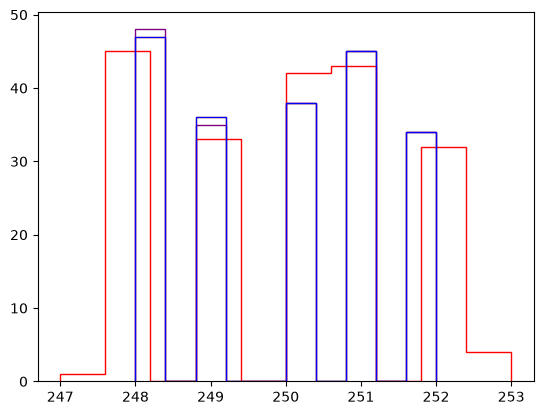

In [6]:
plt.figure(40)
plt.hist(f_max_rec, color = 'orange', histtype='step')
plt.hist(f_max_flat, color = 'red', histtype='step')
plt.hist(f_max_black, color = 'purple', histtype='step')
plt.hist(f_max_cos, color = 'blue', histtype='step')

## Estimaciones

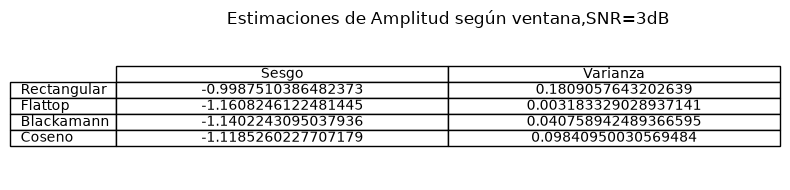

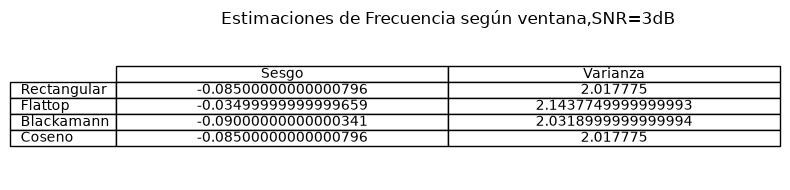

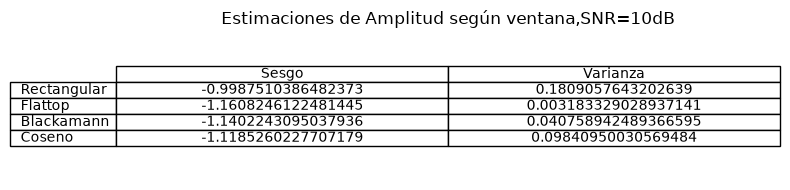

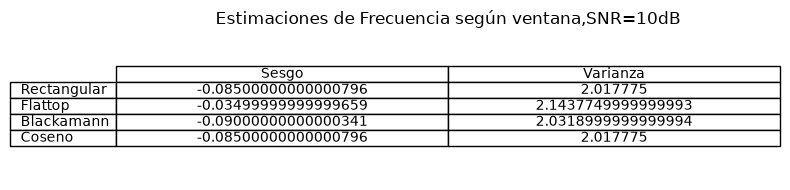

In [7]:
#Tablas de comparacion de amplitud/frecuencia y varianza

##arreglos de datos para tablas
datos_a = [(S_a_rec,V_a_rec),(S_a_flat, V_a_flat),(S_a_black,V_a_black),(S_a_cos,V_a_cos)]

datos_f = [(S_f_rec,V_f_rec),(S_f_flat, V_f_flat),(S_f_black,V_f_black),(S_f_cos,V_f_cos)]

##tabla estimacion amplitud
plt.figure(20,figsize=(8,2))
plt.title("Estimaciones de Amplitud según ventana,SNR=3dB")
tabla_a_3dB = plt.table(
    cellText=(datos_a),
    colLabels=['Sesgo','Varianza'],
    rowLabels=['Rectangular','Flattop','Blackamann','Coseno'],
    loc = 'center',
    cellLoc = 'center'
    )
plt.axis('off')
plt.tight_layout()
plt.show()

##tabla estimacion frecuencia
plt.figure(30,figsize=(8,2))
plt.title("Estimaciones de Frecuencia según ventana,SNR=3dB")
tabla_a_3dB = plt.table(
    cellText=(datos_f),
    colLabels=['Sesgo','Varianza'],
    rowLabels=['Rectangular','Flattop','Blackamann','Coseno'],
    loc = 'center',
    cellLoc = 'center'
    )

plt.axis('off')
plt.tight_layout()
plt.show()




##arreglos de datos para tablas

datos_a = [(S_a_rec,V_a_rec),(S_a_flat, V_a_flat),(S_a_black,V_a_black),(S_a_cos,V_a_cos)]

datos_f = [(S_f_rec,V_f_rec),(S_f_flat, V_f_flat),(S_f_black,V_f_black),(S_f_cos,V_f_cos)]

##tabla estimacion amplitud
plt.figure(50,figsize=(8,2))
plt.title("Estimaciones de Amplitud según ventana,SNR=10dB")
tabla_a_10dB = plt.table(
    cellText=(datos_a),
    colLabels=['Sesgo','Varianza'],
    rowLabels=['Rectangular','Flattop','Blackamann','Coseno'],
    loc = 'center',
    cellLoc = 'center'
    )
plt.axis('off')
plt.tight_layout()
plt.show()

##tabla estimacion frecuencia
plt.figure(60,figsize=(8,2))
plt.title("Estimaciones de Frecuencia según ventana,SNR=10dB")
tabla_f_10dB = plt.table(
    cellText=(datos_f),
    colLabels=['Sesgo','Varianza'],
    rowLabels=['Rectangular','Flattop','Blackamann','Coseno'],
    loc = 'center',
    cellLoc = 'center'
    )

plt.axis('off')
plt.tight_layout()
plt.show()

## Conclusiones

## Referencias
* Holton, Thomas (2021). Digital Signal Processing - Principles and Applications. Cambridge University Press